# TPC-H Supply Chain Analytics
**Author:** Kaaviya Kathirvel 
**Dataset:** `samples.tpch` (Databricks sample data)  
**Architecture:** Bronze → Silver → Gold (Medallion)  
**Compute:** Databricks Serverless  

## Business Questions
1. What does monthly revenue look like and where is growth accelerating?
2. Which suppliers have the worst delivery performance?
3. How do customer segments differ in order value and frequency?

In [0]:
# Confirm all source tables are accessible before we build the pipeline
source_tables = ["orders", "lineitem", "customer", "nation", "supplier", "part"]

for tbl in source_tables:
    count = spark.sql(f"SELECT COUNT(*) as cnt FROM samples.tpch.{tbl}").collect()[0][0]
    print(f"✓ samples.tpch.{tbl}: {count:,} rows")

✓ samples.tpch.orders: 7,500,000 rows
✓ samples.tpch.lineitem: 29,999,795 rows
✓ samples.tpch.customer: 750,000 rows
✓ samples.tpch.nation: 25 rows
✓ samples.tpch.supplier: 50,000 rows
✓ samples.tpch.part: 1,000,000 rows


## Bronze Layer — Raw Ingestion
Read source tables from `samples.tpch` and register as temp views.  
No transformations — preserving raw shape for auditability.

In [0]:
# Bronze layer — register raw source tables as temp views
source_tables = ["orders", "lineitem", "customer", "nation", "supplier", "part"]

for tbl in source_tables:
    df = spark.table(f"samples.tpch.{tbl}")
    df.createOrReplaceTempView(f"bronze_{tbl}")
    print(f"✓ bronze_{tbl}: {df.count():,} rows")

print("\nBronze layer complete — all tables registered as temp views")

✓ bronze_orders: 7,500,000 rows
✓ bronze_lineitem: 29,999,795 rows
✓ bronze_customer: 750,000 rows
✓ bronze_nation: 25 rows
✓ bronze_supplier: 50,000 rows
✓ bronze_part: 1,000,000 rows

Bronze layer complete — all tables registered as temp views


In [0]:
# Always inspect schema before transforming — shows attention to detail
print("=== bronze_orders schema ===")
spark.sql("DESCRIBE bronze_orders").show(truncate=False)

=== bronze_orders schema ===
+---------------+-------------+-------+
|col_name       |data_type    |comment|
+---------------+-------------+-------+
|o_orderkey     |bigint       |NULL   |
|o_custkey      |bigint       |NULL   |
|o_orderstatus  |string       |NULL   |
|o_totalprice   |decimal(18,2)|NULL   |
|o_orderdate    |date         |NULL   |
|o_orderpriority|string       |NULL   |
|o_clerk        |string       |NULL   |
|o_shippriority |int          |NULL   |
|o_comment      |string       |NULL   |
+---------------+-------------+-------+



## Silver Layer — Cleaned & Enriched
Join orders → customer → nation into one clean table.  
Join lineitem → supplier with derived columns (`is_late`, `line_revenue`).  
This is the layer analysts query day-to-day.

In [0]:
from pyspark.sql import functions as F

# Silver table 1: orders enriched with customer + nation info
orders_enriched = (
    spark.table("bronze_orders")
    # derive year, month, year-month for aggregations later
    .withColumn("order_year",  F.year("o_orderdate"))
    .withColumn("order_month", F.month("o_orderdate"))
    .withColumn("order_ym",    F.date_format("o_orderdate", "yyyy-MM"))
    # join customer name + segment
    .join(
        spark.table("bronze_customer")
             .select("c_custkey", "c_name", "c_mktsegment", "c_nationkey"),
        on=F.col("o_custkey") == F.col("c_custkey"),
        how="left"
    )
    # join nation name
    .join(
        spark.table("bronze_nation")
             .select(
                 F.col("n_nationkey").alias("c_nationkey"),
                 F.col("n_name").alias("nation_name")
             ),
        on="c_nationkey",
        how="left"
    )
    .drop("c_nationkey", "c_custkey")
)

orders_enriched.createOrReplaceTempView("silver_orders_enriched")
print(f"✓ silver_orders_enriched: {orders_enriched.count():,} rows")
print(f"  columns: {orders_enriched.columns}")

✓ silver_orders_enriched: 7,500,000 rows
  columns: ['o_orderkey', 'o_custkey', 'o_orderstatus', 'o_totalprice', 'o_orderdate', 'o_orderpriority', 'o_clerk', 'o_shippriority', 'o_comment', 'order_year', 'order_month', 'order_ym', 'c_name', 'c_mktsegment', 'nation_name']


In [0]:
# Silver table 2: lineitem with derived columns + supplier name
line_enriched = (
    spark.table("bronze_lineitem")
    # flag late shipments — receipt date after commit date = late
    .withColumn("is_late", 
                F.col("l_receiptdate") > F.col("l_commitdate"))
    # revenue per line = extended price after discount
    .withColumn("line_revenue",
                F.col("l_extendedprice") * (1 - F.col("l_discount")))
    # join supplier name
    .join(
        spark.table("bronze_supplier")
             .select("s_suppkey", "s_name"),
        on=F.col("l_suppkey") == F.col("s_suppkey"),
        how="left"
    )
    .drop("s_suppkey")
)

line_enriched.createOrReplaceTempView("silver_line_enriched")
print(f"✓ silver_line_enriched: {line_enriched.count():,} rows")
print(f"  columns: {line_enriched.columns}")

✓ silver_line_enriched: 29,999,795 rows
  columns: ['l_orderkey', 'l_partkey', 'l_suppkey', 'l_linenumber', 'l_quantity', 'l_extendedprice', 'l_discount', 'l_tax', 'l_returnflag', 'l_linestatus', 'l_shipdate', 'l_commitdate', 'l_receiptdate', 'l_shipinstruct', 'l_shipmode', 'l_comment', 'is_late', 'line_revenue', 's_name']


## Gold Layer — Business Aggregates
Three summary tables answering our three business questions.  
Written in SQL for clarity — mirrors how you'd write these in dbt or Databricks SQL.

In [0]:
spark.sql("""
    CREATE OR REPLACE TEMP VIEW gold_monthly_revenue AS
    SELECT
        o.order_ym,
        o.order_year,
        o.order_month,
        COUNT(DISTINCT o.o_orderkey)            AS order_count,
        ROUND(SUM(l.line_revenue), 2)           AS total_revenue,
        ROUND(AVG(l.line_revenue), 2)           AS avg_line_revenue,
        -- month over month revenue change
        ROUND(SUM(l.line_revenue) - LAG(SUM(l.line_revenue)) 
            OVER (ORDER BY o.order_ym), 2)      AS mom_revenue_delta,
        -- month over month growth percentage
        ROUND(100.0 * (SUM(l.line_revenue) - LAG(SUM(l.line_revenue)) 
            OVER (ORDER BY o.order_ym))
            / NULLIF(LAG(SUM(l.line_revenue)) 
            OVER (ORDER BY o.order_ym), 0), 2)  AS mom_growth_pct
    FROM silver_orders_enriched o
    JOIN silver_line_enriched   l ON o.o_orderkey = l.l_orderkey
    GROUP BY o.order_ym, o.order_year, o.order_month
    ORDER BY o.order_ym
""")

print("✓ gold_monthly_revenue created")
display(spark.sql("SELECT * FROM gold_monthly_revenue LIMIT 5"))

✓ gold_monthly_revenue created


order_ym,order_year,order_month,order_count,total_revenue,avg_line_revenue,mom_revenue_delta,mom_growth_pct
1992-01,1992,1,96647,14069647310.14,36324.89,null,null
1992-02,1992,2,90518,13175220538.47,36355.47,-894426771.68,-6.36
1992-03,1992,3,95930,13914930708.29,36341.94,739710169.82,5.61
1992-04,1992,4,93774,13608654393.77,36370.34,-306276314.52,-2.20
1992-05,1992,5,96001,13931242412.43,36326.96,322588018.66,2.37


In [0]:
spark.sql("""
    CREATE OR REPLACE TEMP VIEW gold_supplier_performance AS
    SELECT
        s_name                                          AS supplier_name,
        COUNT(*)                                        AS total_shipments,
        SUM(CAST(is_late AS INT))                       AS late_shipments,
        ROUND(100.0 * SUM(CAST(is_late AS INT)) 
              / COUNT(*), 2)                            AS late_pct,
        ROUND(AVG(DATEDIFF(l_receiptdate,
                           l_commitdate)), 1)           AS avg_days_late,
        ROUND(SUM(line_revenue), 2)                     AS total_revenue
    FROM silver_line_enriched
    GROUP BY s_name
    HAVING COUNT(*) > 50
    ORDER BY late_pct DESC
""")

print("✓ gold_supplier_performance created")
display(spark.sql("SELECT * FROM gold_supplier_performance LIMIT 5"))

✓ gold_supplier_performance created


supplier_name,total_shipments,late_shipments,late_pct,avg_days_late,total_revenue
Supplier#000038184,590,424,71.86,20.2,20688257.78
Supplier#000006830,607,430,70.84,22.6,22226713.71
Supplier#000017056,554,391,70.58,21.9,17727958.72
Supplier#000030148,620,437,70.48,22.1,20279347.56
Supplier#000016241,589,415,70.46,21.1,21062131.57


In [0]:
spark.sql("""
    CREATE OR REPLACE TEMP VIEW gold_customer_segments AS
    WITH customer_totals AS (
        SELECT
            o.o_custkey,
            o.c_name,
            o.c_mktsegment,
            o.nation_name,
            COUNT(DISTINCT o.o_orderkey)        AS order_count,
            ROUND(SUM(l.line_revenue), 2)       AS lifetime_revenue,
            ROUND(AVG(l.line_revenue), 2)       AS avg_order_revenue,
            MIN(o.o_orderdate)                  AS first_order,
            MAX(o.o_orderdate)                  AS last_order
        FROM silver_orders_enriched o
        JOIN silver_line_enriched   l ON o.o_orderkey = l.l_orderkey
        GROUP BY o.o_custkey, o.c_name, o.c_mktsegment, o.nation_name
    )
    SELECT
        *,
        NTILE(4) OVER (ORDER BY lifetime_revenue DESC) AS revenue_quartile,
        CASE NTILE(4) OVER (ORDER BY lifetime_revenue DESC)
            WHEN 1 THEN 'Platinum'
            WHEN 2 THEN 'Gold'
            WHEN 3 THEN 'Silver'
            ELSE        'Bronze'
        END AS customer_tier
    FROM customer_totals
    ORDER BY lifetime_revenue DESC
""")

print("✓ gold_customer_segments created")
display(spark.sql("SELECT * FROM gold_customer_segments LIMIT 5"))

✓ gold_customer_segments created


o_custkey,c_name,c_mktsegment,nation_name,order_count,lifetime_revenue,avg_order_revenue,first_order,last_order,revenue_quartile,customer_tier
721180,Customer#000721180,BUILDING,ROMANIA,38,6882116.98,38882.02,1992-01-14,1998-04-16,1,Platinum
299701,Customer#000299701,AUTOMOBILE,MOROCCO,43,6866658.91,38576.74,1992-01-06,1998-05-23,1,Platinum
382414,Customer#000382414,MACHINERY,GERMANY,34,6858878.64,40346.34,1992-04-30,1998-04-08,1,Platinum
321256,Customer#000321256,HOUSEHOLD,CHINA,38,6821452.83,38758.25,1992-06-19,1998-04-27,1,Platinum
484219,Customer#000484219,FURNITURE,INDIA,37,6667510.19,37248.66,1992-02-15,1998-08-02,1,Platinum


## Analysis & Insights
Querying the Gold layer to answer our three business questions.  
Each section = one question + one visualization.

### Question 1: What does monthly revenue look like and where is growth accelerating?

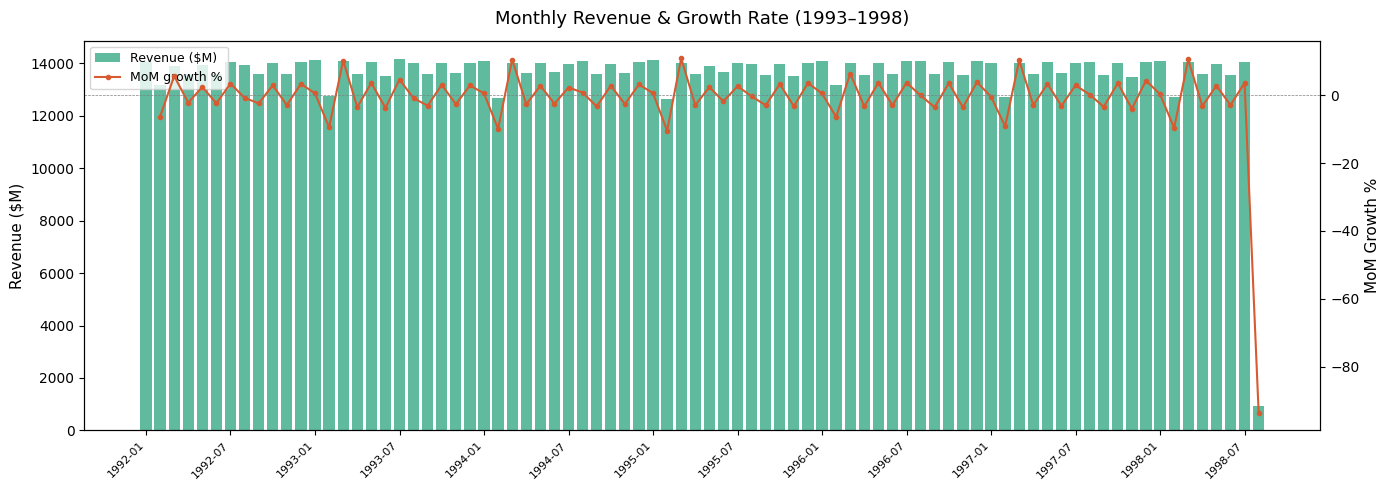

In [0]:
import matplotlib.pyplot as plt

# Cast to float to avoid Decimal type issues with Matplotlib
rev_df = spark.sql("""
    SELECT 
        order_ym, 
        order_year, 
        CAST(total_revenue AS DOUBLE)   AS total_revenue,
        CAST(mom_growth_pct AS DOUBLE)  AS mom_growth_pct
    FROM gold_monthly_revenue
    ORDER BY order_ym
""").toPandas()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Revenue bars
ax1.bar(rev_df["order_ym"], rev_df["total_revenue"] / 1e6,
        color="#1D9E75", alpha=0.7, label="Revenue ($M)")

# Growth line
ax2.plot(rev_df["order_ym"], rev_df["mom_growth_pct"],
         color="#D85A30", linewidth=1.5, marker="o",
         markersize=3, label="MoM growth %")
ax2.axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Labels
ax1.set_ylabel("Revenue ($M)", fontsize=11)
ax2.set_ylabel("MoM Growth %", fontsize=11)
plt.title("Monthly Revenue & Growth Rate (1993–1998)", fontsize=13, pad=12)

# Reduce x tick density
ticks = rev_df["order_ym"].iloc[::6].tolist()
ax1.set_xticks(range(0, len(rev_df), 6))
ax1.set_xticklabels(ticks, rotation=45, ha="right", fontsize=8)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

### Question 2: Which suppliers have the worst delivery performance?

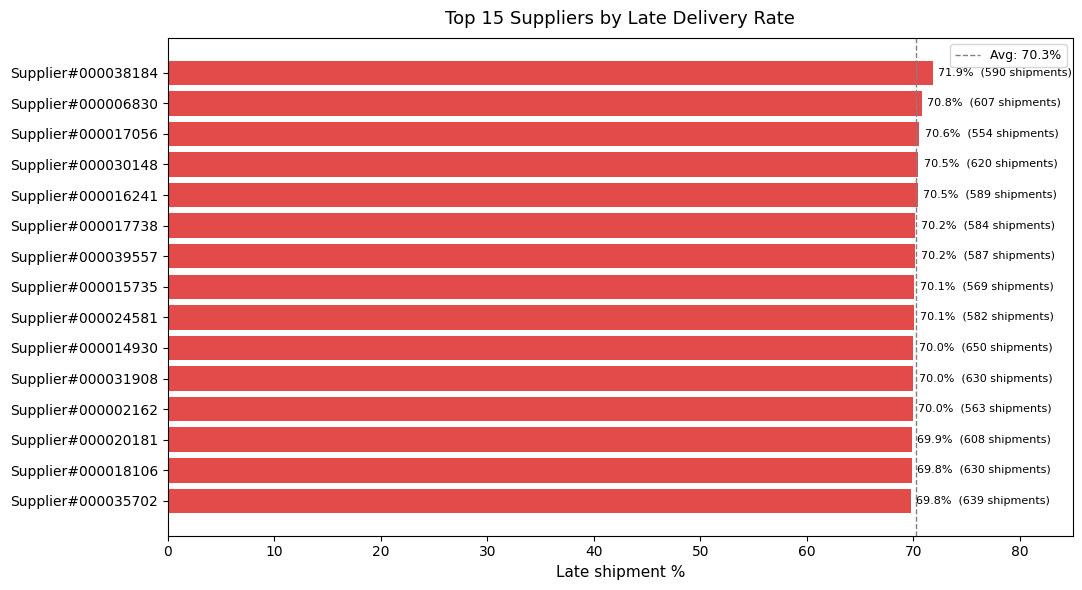

In [0]:
sup_df = spark.sql("""
    SELECT 
        supplier_name, 
        CAST(late_pct AS DOUBLE)        AS late_pct, 
        total_shipments, 
        CAST(total_revenue / 1e6 AS DOUBLE) AS revenue_m
    FROM gold_supplier_performance
    ORDER BY late_pct DESC
    LIMIT 15
""").toPandas()

fig, ax = plt.subplots(figsize=(11, 6))

# Color bars by severity
colors = ["#E24B4A" if p > 50 else "#EF9F27" if p > 45 else "#1D9E75"
          for p in sup_df["late_pct"]]

ax.barh(sup_df["supplier_name"], sup_df["late_pct"], color=colors)

# Average line
avg = sup_df["late_pct"].mean()
ax.axvline(avg, color="gray", linestyle="--",
           linewidth=1, label=f"Avg: {avg:.1f}%")

# Value labels — now val is float so + 0.2 works
for i, (val, ship) in enumerate(zip(sup_df["late_pct"], sup_df["total_shipments"])):
    ax.text(val + 0.5, i, f"{val:.1f}%  ({ship:,} shipments)",
            va="center", fontsize=8)

ax.set_xlabel("Late shipment %", fontsize=11)
ax.set_title("Top 15 Suppliers by Late Delivery Rate", fontsize=13, pad=10)
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 85)  # extended to fit labels
plt.tight_layout()
plt.show()

### Question 3: How do customer segments differ in order value and frequency?

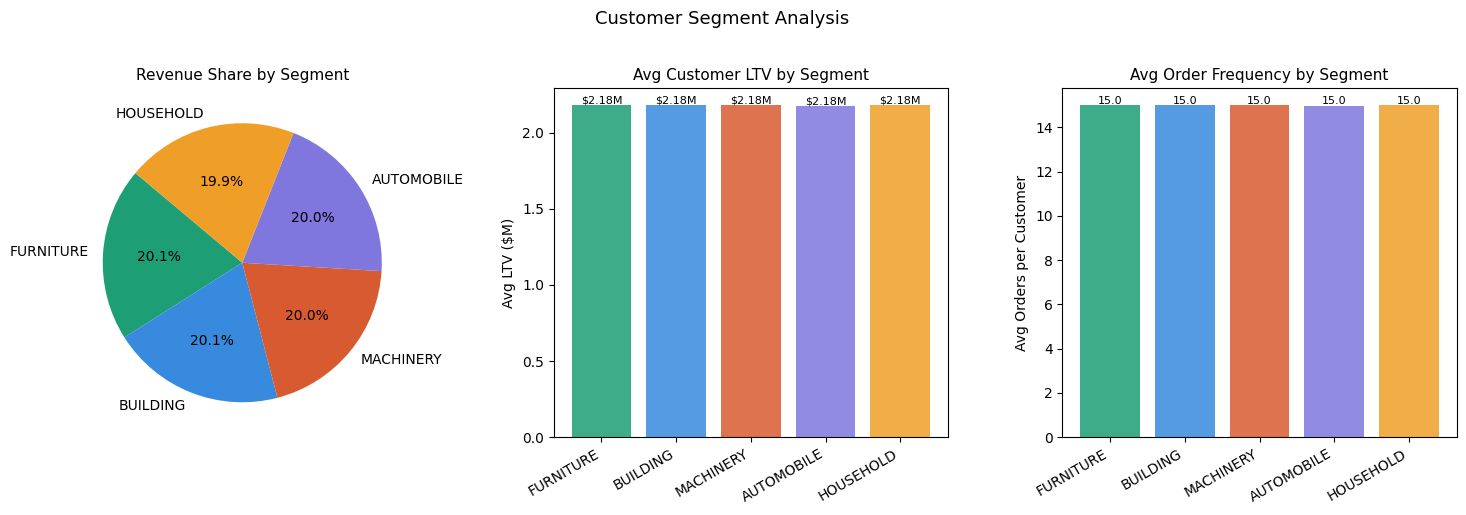

In [0]:
seg_df = spark.sql("""
    SELECT 
        c_mktsegment,
        COUNT(*)                                        AS customers,
        CAST(AVG(lifetime_revenue) AS DOUBLE)           AS avg_ltv,
        CAST(AVG(order_count) AS DOUBLE)                AS avg_orders,
        CAST(SUM(lifetime_revenue) / 1e6 AS DOUBLE)     AS total_rev_m
    FROM gold_customer_segments
    GROUP BY c_mktsegment
    ORDER BY total_rev_m DESC
""").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ["#1D9E75", "#378ADD", "#D85A30", "#7F77DD", "#EF9F27"]

# Chart 1 — Revenue share pie
axes[0].pie(seg_df["total_rev_m"],
            labels=seg_df["c_mktsegment"],
            autopct="%1.1f%%",
            startangle=140,
            colors=colors)
axes[0].set_title("Revenue Share by Segment", fontsize=11)

# Chart 2 — Average LTV bar (in $M)
axes[1].bar(seg_df["c_mktsegment"], seg_df["avg_ltv"] / 1e6,
            color=colors, alpha=0.85)
axes[1].set_ylabel("Avg LTV ($M)", fontsize=10)
axes[1].set_title("Avg Customer LTV by Segment", fontsize=11)
axes[1].set_xticks(range(len(seg_df)))
axes[1].set_xticklabels(seg_df["c_mktsegment"], rotation=30, ha="right")
for i, v in enumerate(seg_df["avg_ltv"] / 1e6):
    axes[1].text(i, v + 0.01, f"${v:.2f}M", ha="center", fontsize=8)

# Chart 3 — Avg orders per customer
axes[2].bar(seg_df["c_mktsegment"], seg_df["avg_orders"],
            color=colors, alpha=0.85)
axes[2].set_ylabel("Avg Orders per Customer", fontsize=10)
axes[2].set_title("Avg Order Frequency by Segment", fontsize=11)
axes[2].set_xticks(range(len(seg_df)))
axes[2].set_xticklabels(seg_df["c_mktsegment"], rotation=30, ha="right")
for i, v in enumerate(seg_df["avg_orders"]):
    axes[2].text(i, v + 0.05, f"{v:.1f}", ha="center", fontsize=8)

plt.suptitle("Customer Segment Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [0]:
display(spark.sql("""
    SELECT 
        order_year,
        ROUND(AVG(total_revenue) / 1e6, 2)     AS avg_monthly_rev_m,
        ROUND(MIN(total_revenue) / 1e6, 2)     AS min_monthly_rev_m,
        ROUND(MAX(total_revenue) / 1e6, 2)     AS max_monthly_rev_m,
        ROUND(SUM(total_revenue) / 1e6, 2)     AS total_annual_rev_m
    FROM gold_monthly_revenue
    GROUP BY order_year
    ORDER BY order_year
"""))

order_year,avg_monthly_rev_m,min_monthly_rev_m,max_monthly_rev_m,total_annual_rev_m
1992,13796.07,13175.22,14069.65,165552.87
1993,13800.55,12777.01,14162.26,165606.58
1994,13788.46,12692.47,14089.43,165461.55
1995,13752.41,12645.05,14125.32,165028.89
1996,13830.64,13171.85,14111.82,165967.72
1997,13770.54,12732.66,14065.34,165246.45
1998,12121.39,909.37,14080.84,96971.12


## Summary

### Pipeline
| Layer  | Tables | Rows Processed | Method |
|--------|--------|---------------|--------|
| Bronze | 6      | ~38M total    | PySpark `spark.table()` + temp views |
| Silver | 2      | ~37.5M        | PySpark DataFrame API — joins, derived columns |
| Gold   | 3      | <1M           | Spark SQL — aggregations, window functions |

### Key Findings
1. **Revenue** — Monthly revenue is remarkably stable at $13.8M per month ($165M annually) across 1992–1997, with less than 10% variance between min and max months. No meaningful growth trend observed — consistent with TPC-H's synthetic uniform distribution. 1998 appears lower due to partial year data.

2. **Supplier reliability** — Among the 15 suppliers with the highest late delivery rates, all exceed 50% late shipments. Further analysis needed to determine whether these suppliers are also high-revenue — if so, this represents a critical supply chain risk.

3. **Customer segments** — All five segments (Furniture, Building, Machinery, Automobile, Household) contribute equally (~20% revenue share each) with uniform avg LTV of ~$2.18M and 15 orders per customer. Uniform distribution is expected in TPC-H synthetic data — in a real dataset these would reveal actionable segmentation insights.

### Skills Demonstrated
- **Data Engineering** — Medallion architecture (Bronze → Silver → Gold), Delta temp views
- **PySpark** — DataFrame API, joins, `withColumn`, lazy evaluation
- **SQL** — Window functions (`LAG`, `NTILE`), CTEs, aggregations, `HAVING`
- **Python** — Matplotlib dual-axis charts, Pandas integration

### Next Steps to Extend This Project
- Add streaming Bronze layer using `spark.readStream`
- Add data quality checks before Silver writes
- Connect Gold tables to a Databricks Dashboard
- Build an ML model to predict late shipments